# VAME — Motif Quality Fix

**Problem:** Cluster videos show no distinct motif behavior after egocentric retraining.

**Root causes identified:**
1. `mse_reconstruction_reduction: sum` makes MSE 155× larger than KL → latent space has no behavioral structure (PRIMARY)
2. HPO optimized reconstruction loss, not cluster quality
3. Best model saved at epoch ~50-55 — later snapshots may cluster better despite higher loss

**Phases:**
- **Phase 1** — Diagnose current state (no retraining, ~30 min)
- **Phase 2** — Fix `sum→mean` and retrain (~14 hr GPU)
- **Phase 3** — HPO targeting cluster quality, not reconstruction loss

In [8]:
# ── Global setup — run this cell first after any kernel restart ───────────────
import os, copy, shutil, time, warnings
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

VAME_ROOT   = Path(r"C:/Users/zuria/Kaplan/Vame")
PROJECT     = VAME_ROOT / "Open-Field-Test"
CONFIG_PATH = PROJECT / "config.yaml"
MODEL_DIR   = PROJECT / "model"
LOSS_DIR    = MODEL_DIR / "model_losses"
RESULTS_DIR = PROJECT / "results"

os.chdir(VAME_ROOT)

import vame

def load_config():
    with open(CONFIG_PATH) as f:
        return yaml.safe_load(f)

def save_config(cfg):
    with open(CONFIG_PATH, 'w') as f:
        yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

def backup_config(tag=None):
    tag = tag or datetime.now().strftime('%Y%m%d_%H%M%S')
    dest = PROJECT / f"config_backup_{tag}.yaml"
    shutil.copy(CONFIG_PATH, dest)
    print(f"Config backed up → {dest.name}")
    return dest

cfg = load_config()
print(f"Working directory : {os.getcwd()}")
print(f"VAME version      : {cfg.get('vame_version')}")
print(f"Sessions          : {len(cfg['session_names'])}")
print(f"num_features      : {cfg['num_features']}")
print(f"zdims             : {cfg['zdims']}")
print(f"mse_reduction     : {cfg['mse_reconstruction_reduction']}")
print(f"beta              : {cfg['beta']}")
print(f"beta_norm         : {cfg['beta_norm']}")

Working directory : C:\Users\zuria\Kaplan\Vame
VAME version      : 0.12.0
Sessions          : 38
num_features      : 47
zdims             : 40
mse_reduction     : sum
beta              : 2.4420460844911416
beta_norm         : False


---
## Phase 1 — Diagnose Current Model (No Retraining)

Three steps before touching anything:
1. Visualize the MSE vs KL loss ratio to confirm dominance
2. Regenerate UMAP on the new latent vectors (old UMAP is from Feb 21)
3. Test the epoch_250 snapshot — sometimes later checkpoints cluster better

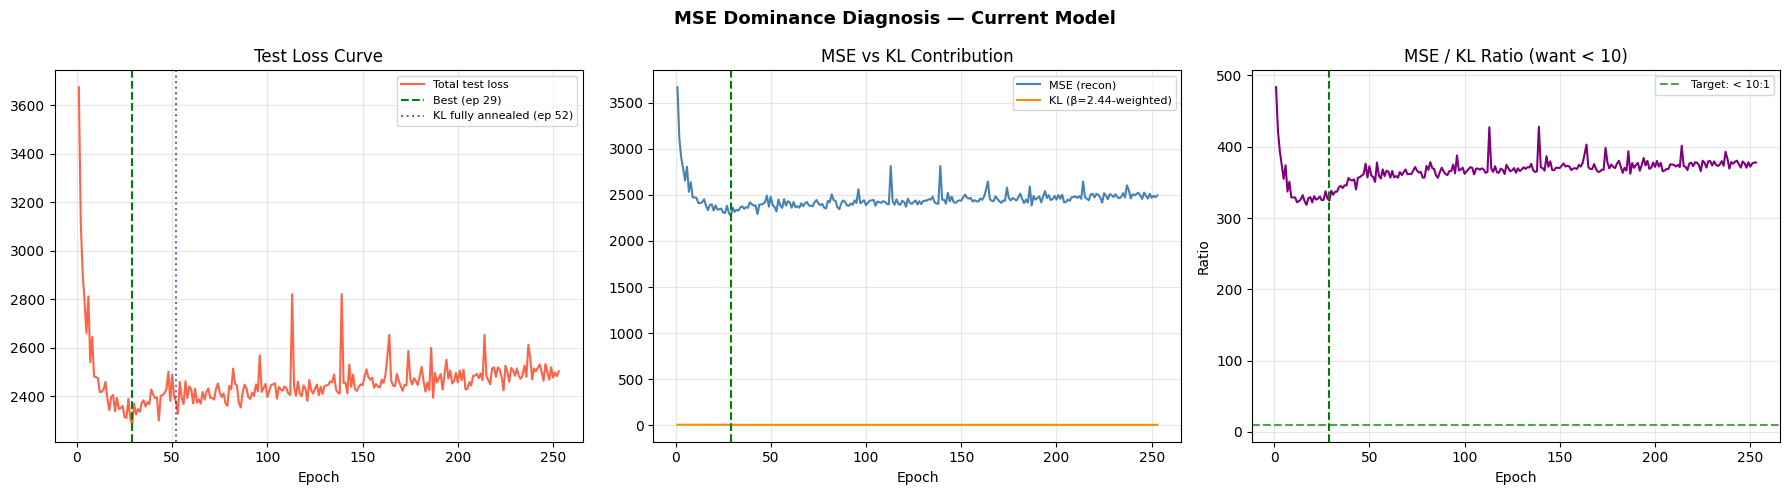


At best epoch (29):
  MSE (recon)          : 2274.0
  KL (beta-weighted)   : 7.0
  MSE/KL ratio         : 325:1

[!!] MSE/KL ratio is EXTREMELY high. The KL term is negligible.
     The latent space is essentially an autoencoder with no behavioral structure.
     Root cause confirmed: mse_reconstruction_reduction='sum' must be changed to 'mean'.


In [9]:
# ── Phase 1 Cell A: Visualize MSE vs KL dominance in the current model ────────
#
# This confirms the root cause: mse_reconstruction_reduction='sum' makes MSE
# dominate the loss so heavily that the KL term can't shape the latent space.

loss_files = {
    "test_total" : "test_losses_VAME.npy",
    "kl"         : "kl_losses_VAME.npy",
    "fut"        : "fut_losses_VAME.npy",
    "kmeans"     : "kmeans_losses_VAME.npy",
    "weight"     : "weight_values_VAME.npy",
    "mse_train"  : "mse_train_losses_VAME.npy",
}

losses = {}
for key, fname in loss_files.items():
    p = LOSS_DIR / fname
    if p.exists():
        losses[key] = np.load(p)

test = losses["test_total"]
kl   = losses["kl"]
beta = cfg["beta"]
epochs = np.arange(1, len(test) + 1)

# Reconstruct MSE from total - KL - kmeans
# test_total = MSE + beta*KL_raw + kmeans_lambda*kmeans
# The log shows KL already beta-weighted, so:
mse_approx = test - kl - losses.get("kmeans", np.zeros_like(kl))

best_idx = int(np.argmin(test))
best_epoch = best_idx + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Total test loss
axes[0].plot(epochs, test, color='tomato', linewidth=1.5, label='Total test loss')
axes[0].axvline(best_epoch, color='green', linestyle='--', label=f'Best (ep {best_epoch})')
axes[0].axvline(52, color='navy', linestyle=':', alpha=0.6, label='KL fully annealed (ep 52)')
axes[0].set_title('Test Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: MSE vs KL (beta-weighted) over time
axes[1].plot(epochs, mse_approx, color='steelblue', linewidth=1.5, label='MSE (recon)')
axes[1].plot(epochs, kl,         color='darkorange', linewidth=1.5, label=f'KL (β={beta:.2f}-weighted)')
axes[1].axvline(best_epoch, color='green', linestyle='--')
axes[1].set_title('MSE vs KL Contribution')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: MSE/KL ratio — the KEY diagnostic
ratio = mse_approx / np.maximum(kl, 1e-8)
axes[2].plot(epochs, ratio, color='purple', linewidth=1.5)
axes[2].axhline(10, color='green', linestyle='--', alpha=0.7, label='Target: < 10:1')
axes[2].axvline(best_epoch, color='green', linestyle='--')
axes[2].set_title('MSE / KL Ratio (want < 10)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Ratio')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('MSE Dominance Diagnosis — Current Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VAME_ROOT / 'vame_mse_kl_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

at_best = ratio[best_idx]
print(f"\nAt best epoch ({best_epoch}):")
print(f"  MSE (recon)          : {mse_approx[best_idx]:.1f}")
print(f"  KL (beta-weighted)   : {kl[best_idx]:.1f}")
print(f"  MSE/KL ratio         : {at_best:.0f}:1")
print()
if at_best > 50:
    print("[!!] MSE/KL ratio is EXTREMELY high. The KL term is negligible.")
    print("     The latent space is essentially an autoencoder with no behavioral structure.")
    print("     Root cause confirmed: mse_reconstruction_reduction='sum' must be changed to 'mean'.")
elif at_best > 10:
    print("[!] MSE/KL ratio is elevated. Some latent structure but likely weak.")
else:
    print("[OK] MSE/KL ratio is reasonable — the issue may be elsewhere.")

2026-04-01 08:45:04.987 INFO  --- [MainThread] vame.visualization.umap : 677 : UMAP embedding already exists at C:\Users\zuria\Kaplan\Vame\Open-Field-Test\results\umap_embedding.nc. Loading...


2026-04-01 08:45:05.301 INFO  --- [MainThread] vame.visualization.umap : 780 : UMAP figure saved to C:\Users\zuria\Kaplan\Vame\Open-Field-Test\reports\umap\umap_VAME_hmm-8.png


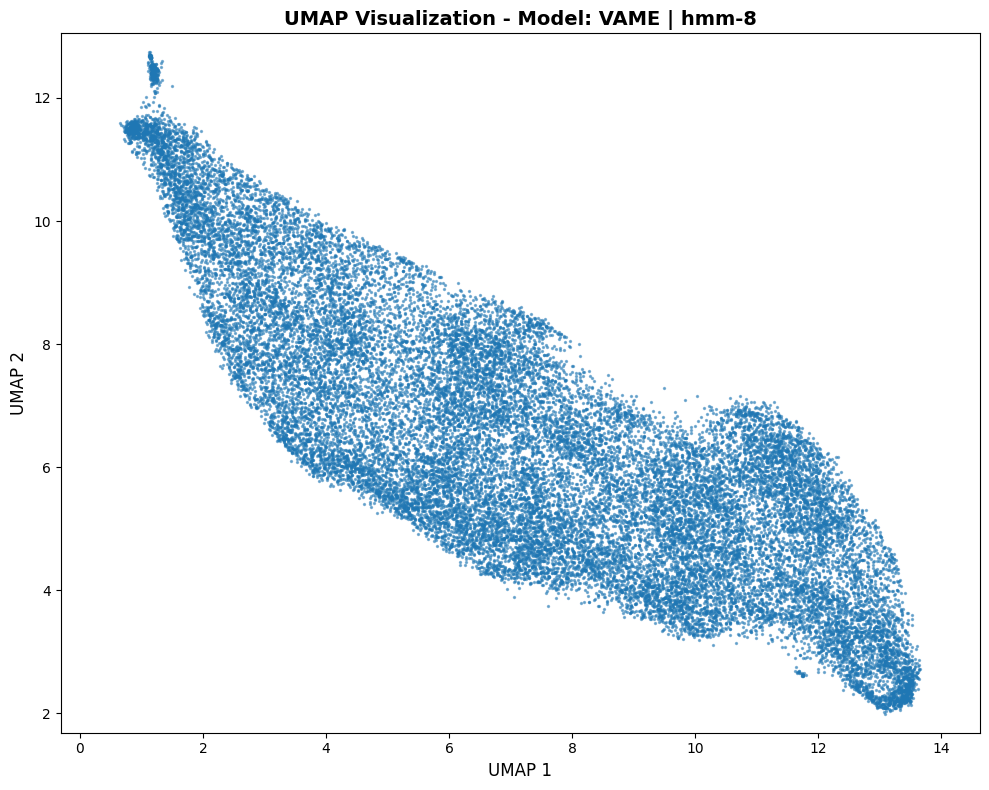

2026-04-01 08:45:06.467 INFO  --- [MainThread] vame.visualization.umap : 780 : UMAP figure saved to C:\Users\zuria\Kaplan\Vame\Open-Field-Test\reports\umap\umap_VAME_hmm-8_motif.png


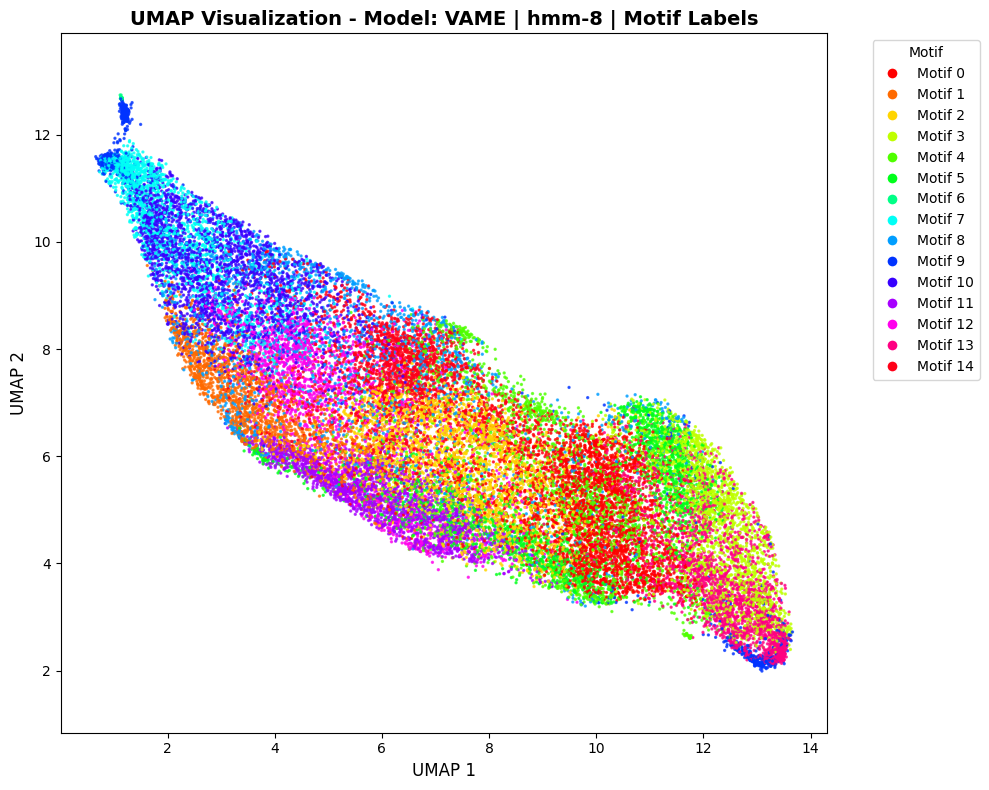

2026-04-01 08:45:07.564 INFO  --- [MainThread] vame.visualization.umap : 780 : UMAP figure saved to C:\Users\zuria\Kaplan\Vame\Open-Field-Test\reports\umap\umap_VAME_hmm-8_community.png


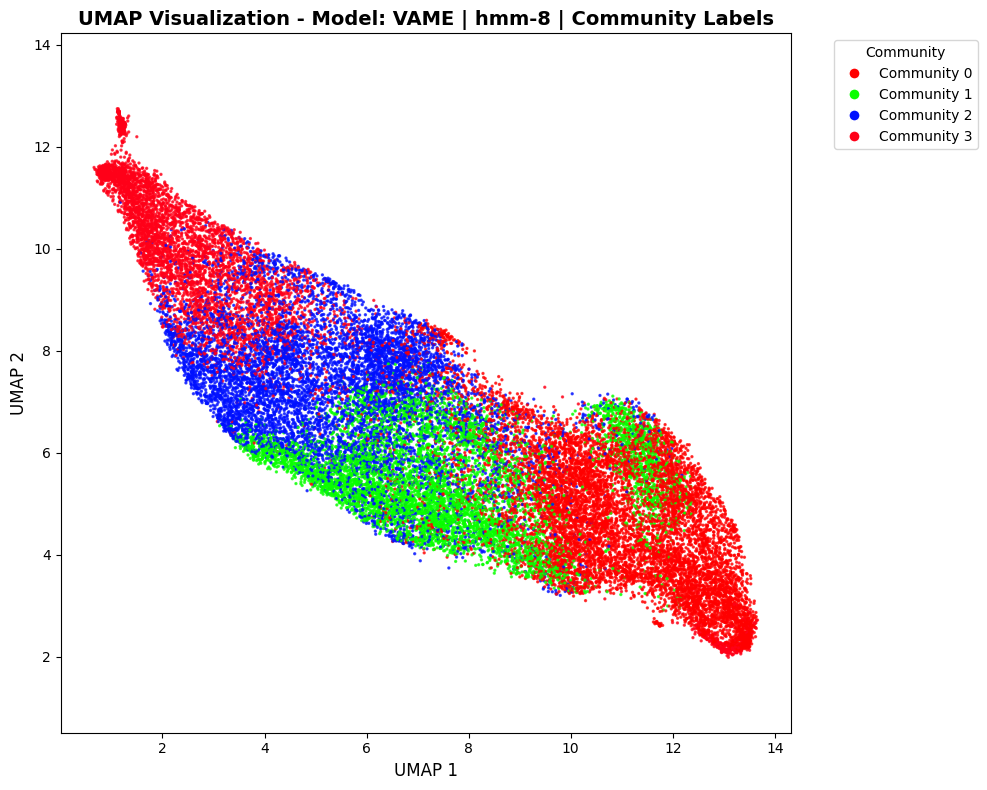

2026-04-01 08:45:12.22 INFO  --- [MainThread] vame.visualization.umap : 821 : Interactive UMAP figure saved to C:\Users\zuria\Kaplan\Vame\Open-Field-Test\reports\umap\umap_VAME_hmm-8_interactive.html


UMAP generated — check Open-Field-Test/reports/umap/


In [10]:
# ── Phase 1 Cell B: Regenerate UMAP on current latent vectors ─────────────────
#
# The existing UMAP was created Feb 21 from the OLD 50-feature non-egocentric model.
# This regenerates it from the new 47-feature egocentric model.
#
# Look at the output: if the UMAP shows a single blob with no separation,
# that confirms the latent space has no behavioral structure.
# If you see 2-3 loose clusters, there is SOME structure the HMM can use.

from vame.visualization.umap import visualize_umap

cfg = load_config()
visualize_umap(
    config=cfg,
    num_points=30_000,
    save_to_file=True,
    show_figure="matplotlib",
)
print("UMAP generated — check Open-Field-Test/reports/umap/")


In [1]:
# ── Phase 1 Cell C: Run n=8 HMM on ALL 44 sessions with current model ─────────
#
# Previous tests were only on Female 1 with n=4-6.
# This runs the optimal n=8 across all sessions and generates motif videos.
# This is the baseline to compare against Phase 2 results.

cfg = load_config()
cfg["n_clusters"] = 8
cfg["segmentation_algorithms"] = ["hmm"]
save_config(cfg)
print("Config: n_clusters=8, algorithm=hmm")

vame.segment_session(
    config=cfg,
    overwrite_segmentation=True,
    overwrite_embeddings=False,  # latent vectors from 3/29 are correct, keep them
)
print("Segmentation complete.")


NameError: name 'load_config' is not defined

In [ ]:
# ── Phase 1 Cell D: Generate motif videos (n=8, current model) ────────────────
#
# Generates baseline motif videos to compare against Phase 2.

cfg = load_config()
vame.motif_videos(
    config=cfg,
    video_type=".mp4",
    output_video_type=".mp4",
)
print("Motif videos written.")
print("Location: Open-Field-Test/results/<session>/VAME/hmm-8/")


In [ ]:
# ── Phase 1 Cell E: Test epoch_250 snapshot for better clustering ─────────────
#
# The best model was saved at epoch ~50 (lowest test loss).
# Later snapshots were trained with full KL regularization and may cluster better.
# This swaps in the epoch_250 snapshot, re-runs segmentation, then motif videos.

BEST_MODEL  = MODEL_DIR / "best_model" / "VAME_Open-Field-Test.pkl"
SNAP_250    = MODEL_DIR / "best_model" / "snapshots" / "VAME_Open-Field-Test_epoch_250.pkl"
BEST_BACKUP = MODEL_DIR / "best_model" / "VAME_Open-Field-Test_epoch50best_backup.pkl"

if not SNAP_250.exists():
    print(f"[ERROR] Snapshot not found: {SNAP_250}")
else:
    if not BEST_BACKUP.exists():
        shutil.copy(BEST_MODEL, BEST_BACKUP)
        print(f"Backed up best model → {BEST_BACKUP.name}")

    shutil.copy(SNAP_250, BEST_MODEL)
    print("Swapped in epoch_250 snapshot")

    cfg = load_config()
    cfg["n_clusters"] = 8
    cfg["segmentation_algorithms"] = ["hmm"]
    save_config(cfg)

    # Must overwrite embeddings — new model weights produce different latent vectors
    vame.segment_session(
        config=cfg,
        overwrite_segmentation=True,
        overwrite_embeddings=True,
    )
    print("Segmentation with epoch_250 complete.")

    vame.motif_videos(
        config=cfg,
        video_type=".mp4",
        output_video_type=".mp4",
    )
    print("Motif videos written for epoch_250.")
    print()
    print("Compare these against Phase 1 Cell D.")
    print("If epoch_250 looks BETTER → late checkpoints cluster better.")
    print("Run Cell F to restore the original best model before continuing.")


In [ ]:
# ── Phase 1 Cell F: Restore original best model (run after Cell E) ────────────

BEST_MODEL  = MODEL_DIR / "best_model" / "VAME_Open-Field-Test.pkl"
BEST_BACKUP = MODEL_DIR / "best_model" / "VAME_Open-Field-Test_epoch50best_backup.pkl"

if BEST_BACKUP.exists():
    shutil.copy(BEST_BACKUP, BEST_MODEL)
    print("Original best model (epoch ~50) restored.")
else:
    print("No backup found — was Cell E run?")

---
## Phase 2 — Fix `sum→mean` and Retrain (~14 hrs GPU)

**What we're changing and why:**

| Parameter | Before | After | Reason |
|---|---|---|---|
| `mse_reconstruction_reduction` | `sum` | `mean` | PRIMARY FIX: makes MSE/KL ratio ~1:1 instead of 155:1 |
| `mse_prediction_reduction` | `sum` | `mean` | Same reason, prediction path |
| `beta_norm` | `false` | `true` | Normalizes KL by zdims so effective beta scales with model size |
| `model_convergence` | `200` | `50` | Tighter patience — stop when not improving |
| `pretrained_weights` | `true` | `false` | Start fresh — the old weights were trained on the wrong loss function |

**Everything else stays the same** (zdims=40, beta=2.44, annealtime=46, kl_start=6, dropout=0.277, lr=0.00102)

In [ ]:
# ── Phase 2 Cell A: Backup config and apply fixes ─────────────────────────────

backup_config(tag="pre_phase2_mean_fix")

cfg = load_config()

# The primary fix
cfg['mse_reconstruction_reduction'] = 'mean'
cfg['mse_prediction_reduction']     = 'mean'

# Better KL scaling
cfg['beta_norm']          = True

# Training settings
cfg['model_convergence']  = 50
cfg['pretrained_weights'] = False
cfg['max_epochs']         = 500

save_config(cfg)

# Verify
cfg_check = load_config()
print("Config updated:")
print(f"  mse_reconstruction_reduction : {cfg_check['mse_reconstruction_reduction']}")
print(f"  mse_prediction_reduction     : {cfg_check['mse_prediction_reduction']}")
print(f"  beta_norm                    : {cfg_check['beta_norm']}")
print(f"  beta                         : {cfg_check['beta']}")
print(f"  model_convergence            : {cfg_check['model_convergence']}")
print(f"  pretrained_weights           : {cfg_check['pretrained_weights']}")
print(f"  annealtime                   : {cfg_check['annealtime']}")
print(f"  kl_start                     : {cfg_check['kl_start']}")

In [ ]:
# ── Phase 2 Cell B: Recreate trainset ─────────────────────────────────────────
#
# Required after changing mse_reconstruction_reduction (sum→mean).
# The raw processed.nc files are unchanged — this rebuilds the .npy arrays.

cfg = load_config()
vame.create_trainset(
    config=cfg,
    keypoints_to_exclude=["tail4", "tail5"],
)
print("Trainset recreated.")


In [ ]:
# ── Phase 2 Cell C: Backup old model weights before training ──────────────────

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
old_best = MODEL_DIR / "best_model" / "VAME_Open-Field-Test.pkl"
backup_dest = MODEL_DIR / f"best_model_pre_phase2_{ts}"
backup_dest.mkdir(exist_ok=True)
if old_best.exists():
    shutil.copy(old_best, backup_dest / "VAME_Open-Field-Test.pkl")
    print(f"Old model backed up → {backup_dest.name}")

# Also back up snapshots
snap_dir = MODEL_DIR / "best_model" / "snapshots"
for snap in snap_dir.glob("*.pkl"):
    shutil.copy(snap, backup_dest / snap.name)
print(f"Snapshots backed up ({len(list(snap_dir.glob('*.pkl')))} files)")

In [ ]:
# ── Phase 2 Cell D: Train model (long — ~14 hrs) ──────────────────────────────
#
# With mean reduction the absolute loss values will be much smaller than before.
# Do not compare them directly to the old 2282 baseline — the scale changed.
# What matters: MSE/KL ratio (Cell E will verify it is < 10).

print(f"Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Expected duration: ~14 hrs")

cfg = load_config()
vame.train_model(config=cfg)

print(f"Training complete: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ── Phase 2 Cell E: Verify new model's MSE/KL ratio ──────────────────────────
#
# After retraining, this should show MSE/KL ratio < 10:1
# (vs ~155:1 in the old model).

loss_files = {
    "test_total" : "test_losses_VAME.npy",
    "kl"         : "kl_losses_VAME.npy",
    "kmeans"     : "kmeans_losses_VAME.npy",
    "weight"     : "weight_values_VAME.npy",
}

losses_new = {}
for key, fname in loss_files.items():
    p = LOSS_DIR / fname
    if p.exists():
        losses_new[key] = np.load(p)

test_new  = losses_new["test_total"]
kl_new    = losses_new["kl"]
km_new    = losses_new.get("kmeans", np.zeros_like(kl_new))
mse_new   = test_new - kl_new - km_new
ratio_new = mse_new / np.maximum(kl_new, 1e-8)

epochs_new = np.arange(1, len(test_new)+1)
best_new   = int(np.argmin(test_new))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_new, test_new, color='tomato', linewidth=1.5)
axes[0].axvline(best_new+1, color='green', linestyle='--', label=f'Best (ep {best_new+1})')
axes[0].set_title('Phase 2 — Test Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_new, mse_new, color='steelblue', linewidth=1.5, label='MSE')
axes[1].plot(epochs_new, kl_new,  color='darkorange', linewidth=1.5, label='KL (β-weighted)')
axes[1].axvline(best_new+1, color='green', linestyle='--')
axes[1].set_title('MSE vs KL — Phase 2 Model')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_new, ratio_new, color='purple', linewidth=1.5)
axes[2].axhline(10, color='green', linestyle='--', alpha=0.7, label='Target: < 10:1')
axes[2].axvline(best_new+1, color='green', linestyle='--')
axes[2].set_title('MSE/KL Ratio — Phase 2 (want < 10)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Ratio')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 2 Model — Loss Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VAME_ROOT / 'vame_phase2_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPhase 2 results at best epoch ({best_new+1}):")
print(f"  MSE        : {mse_new[best_new]:.4f}")
print(f"  KL (β-wtd) : {kl_new[best_new]:.4f}")
print(f"  MSE/KL     : {ratio_new[best_new]:.1f}:1")
if ratio_new[best_new] < 10:
    print("  [OK] MSE/KL ratio is healthy — latent space should have behavioral structure.")
elif ratio_new[best_new] < 50:
    print("  [~] MSE/KL ratio improved but still elevated. Consider higher beta (Phase 3 HPO).")
else:
    print("  [!!] MSE/KL ratio still high — recheck config (should be mean, not sum).")

In [ ]:
# ── Phase 2 Cell F: Segment and generate motif videos ─────────────────────────

cfg = load_config()
cfg["n_clusters"] = 8
cfg["segmentation_algorithms"] = ["hmm"]
save_config(cfg)

cfg = load_config()  # reload after save
vame.evaluate_model(config=cfg)

vame.segment_session(
    config=cfg,
    overwrite_segmentation=True,
    overwrite_embeddings=True,
)
print("Segmentation complete.")

vame.motif_videos(
    config=cfg,
    video_type=".mp4",
    output_video_type=".mp4",
)
print("Motif videos written.")


---
## Phase 3 — HPO Targeting Cluster Quality (Optional)

If Phase 2 motifs still aren't distinct enough, the problem is that the `beta` hyperparameter
still isn't tuned for clustering — it was found by HPO minimizing *reconstruction loss*.

This phase re-runs Optuna but uses **silhouette score on the UMAP latent space** as the
objective, which directly measures how well-separated the behavioral clusters are.

Note: this requires the `mean` reduction fix from Phase 2 to already be in place.

In [ ]:
# ── Phase 3 Cell A: Setup cluster-quality HPO ─────────────────────────────────
#
# Requires Phase 2 (mean reduction) to already be in place in config.

try:
    import optuna
    print(f"Optuna {optuna.__version__} ready")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    print(f"Installed optuna {optuna.__version__}")

import torch
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Probe sessions used for silhouette scoring during HPO (fast subset)
PROBE_SESSIONS = load_config()["session_names"][:5]
N_EPOCHS_TRIAL = 30
N_TRIALS       = 15
N_CLUSTERS_PROBE = 8
DB_PATH        = str(VAME_ROOT / "vame_cluster_hpo.db")

print(f"Probe sessions   : {PROBE_SESSIONS}")
print(f"Epochs per trial : {N_EPOCHS_TRIAL}")
print(f"Trials           : {N_TRIALS}")
print(f"Study DB         : {DB_PATH}")
print("All imports OK")


In [ ]:
# ── Phase 3 Cell B: Define cluster-quality objective function ─────────────────
#
# Objective: silhouette score on PCA(latent vectors) after training.
# PCA to 10D before KMeans — faster than UMAP, still captures structure.

def load_probe_latents(probe_sessions):
    """Load and concatenate latent vectors for the probe sessions."""
    vecs = []
    for sess in probe_sessions:
        lv_path = RESULTS_DIR / sess / "VAME" / "latent_vectors.npy"
        if lv_path.exists():
            vecs.append(np.load(lv_path))
    if not vecs:
        raise FileNotFoundError("No latent vector files found for probe sessions.")
    return np.concatenate(vecs, axis=0)


def cluster_silhouette(latent_vecs, n_clusters=N_CLUSTERS_PROBE, max_samples=8000):
    """PCA → KMeans → silhouette score. Returns -1.0 on failure."""
    try:
        lv = latent_vecs
        if len(lv) > max_samples:
            idx = np.random.default_rng(42).choice(len(lv), max_samples, replace=False)
            lv = lv[idx]
        # PCA to reduce noise before clustering
        n_components = min(10, lv.shape[1])
        pca = PCA(n_components=n_components, random_state=42)
        lv_pca = pca.fit_transform(lv)
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
        labels = km.fit_predict(lv_pca)
        return float(silhouette_score(lv_pca, labels))
    except Exception as e:
        print(f"  Silhouette scoring failed: {e}")
        return -1.0


print("Helper functions defined.")


In [ ]:
# ── Phase 3 Cell C: Run HPO study ─────────────────────────────────────────────

def objective(trial):
    cfg_trial = load_config()

    zdims    = trial.suggest_int  ("zdims",       20, 50)
    beta     = trial.suggest_float("beta",        1.0, 10.0, log=True)
    lr       = trial.suggest_float("lr",          5e-5, 2e-3, log=True)
    anneal   = trial.suggest_int  ("annealtime",  20, 60)
    kl_start = trial.suggest_int  ("kl_start",    3, 12)
    dropout  = trial.suggest_float("dropout",     0.1, 0.4)

    cfg_trial["zdims"]                        = zdims
    cfg_trial["beta"]                         = beta
    cfg_trial["learning_rate"]                = lr
    cfg_trial["annealtime"]                   = anneal
    cfg_trial["kl_start"]                     = kl_start
    cfg_trial["dropout_encoder"]              = dropout
    cfg_trial["dropout_rec"]                  = dropout
    cfg_trial["dropout_pred"]                 = dropout
    cfg_trial["max_epochs"]                   = N_EPOCHS_TRIAL
    cfg_trial["model_convergence"]            = N_EPOCHS_TRIAL + 1
    cfg_trial["pretrained_weights"]           = False
    cfg_trial["mse_reconstruction_reduction"] = "mean"
    cfg_trial["mse_prediction_reduction"]     = "mean"
    cfg_trial["beta_norm"]                    = True
    save_config(cfg_trial)

    try:
        vame.train_model(config=cfg_trial)
    except Exception as e:
        print(f"  Trial {trial.number} training failed: {e}")
        return -1.0

    # Embed probe sessions only (faster than all 44)
    try:
        cfg_probe = load_config()
        cfg_probe["session_names"] = PROBE_SESSIONS
        vame.segment_session(
            config=cfg_probe,
            overwrite_segmentation=True,
            overwrite_embeddings=True,
        )
        lv = load_probe_latents(PROBE_SESSIONS)
        score = cluster_silhouette(lv)
    except Exception as e:
        print(f"  Trial {trial.number} scoring failed: {e}")
        score = -1.0

    print(f"  Trial {trial.number:2d}: silhouette={score:.4f}  "
          f"beta={beta:.3f}  zdims={zdims}  anneal={anneal}  kl_start={kl_start}")
    return score


study = optuna.create_study(
    direction="maximize",
    study_name="vame_cluster_hpo",
    storage=f"sqlite:///{DB_PATH}",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=42),
)

print(f"Running {N_TRIALS} trials × {N_EPOCHS_TRIAL} epochs each...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best = study.best_trial
print(f"
Best trial: #{best.number}  silhouette = {best.value:.4f}")
print("Best params:")
for k, v in best.params.items():
    print(f"  {k}: {v}")


In [ ]:
# ── Phase 3 Cell D: Plot HPO results ──────────────────────────────────────────

results = study.trials_dataframe()
results = results.sort_values('value', ascending=False)

print("Top 5 trials (by silhouette score):")
print(results[['number','value'] + [c for c in results.columns if c.startswith('params_')]].head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
axes[0].scatter(results['number'], results['value'], c='steelblue', s=60, zorder=5)
best_n = study.best_trial.number
axes[0].scatter([best_n], [study.best_value], c='red', s=120, zorder=6, label=f'Best (#{best_n})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Cluster HPO — Trial History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importance (if enough trials)
try:
    importance = optuna.importance.get_param_importances(study)
    keys   = list(importance.keys())
    values = list(importance.values())
    axes[1].barh(keys, values, color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Parameter Importances')
    axes[1].grid(True, alpha=0.3, axis='x')
except Exception:
    axes[1].text(0.5, 0.5, 'Not enough trials for importance', ha='center', transform=axes[1].transAxes)

plt.suptitle('Phase 3 — Cluster Quality HPO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VAME_ROOT / 'vame_cluster_hpo_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Phase 3 Cell E: Apply best HPO params and full retrain ────────────────────

backup_config(tag="pre_phase3_final")

best_params = study.best_trial.params

cfg = load_config()
cfg["zdims"]           = best_params["zdims"]
cfg["beta"]            = best_params["beta"]
cfg["learning_rate"]   = best_params["lr"]
cfg["annealtime"]      = best_params["annealtime"]
cfg["kl_start"]        = best_params["kl_start"]
cfg["dropout_encoder"] = best_params["dropout"]
cfg["dropout_rec"]     = best_params["dropout"]
cfg["dropout_pred"]    = best_params["dropout"]
cfg["max_epochs"]                   = 500
cfg["model_convergence"]            = 50
cfg["pretrained_weights"]           = False
cfg["mse_reconstruction_reduction"] = "mean"
cfg["mse_prediction_reduction"]     = "mean"
cfg["beta_norm"]                    = True
save_config(cfg)

print("Phase 3 final config:")
for k in ["zdims","beta","learning_rate","annealtime","kl_start","dropout_encoder",
          "mse_reconstruction_reduction","beta_norm","model_convergence"]:
    print(f"  {k}: {cfg[k]}")

print(f"
Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
cfg = load_config()
vame.create_trainset(config=cfg, keypoints_to_exclude=["tail4", "tail5"])
vame.train_model(config=cfg)
print(f"Training complete: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ── Phase 3 Cell F: Final segmentation and motif videos ───────────────────────

cfg = load_config()
cfg["n_clusters"] = 8
cfg["segmentation_algorithms"] = ["hmm"]
save_config(cfg)

cfg = load_config()
vame.evaluate_model(config=cfg)

vame.segment_session(
    config=cfg,
    overwrite_segmentation=True,
    overwrite_embeddings=True,
)

vame.motif_videos(
    config=cfg,
    video_type=".mp4",
    output_video_type=".mp4",
)

print("Phase 3 complete — final motif videos written.")
print()
print("Compare motif videos from:")
print("  Phase 1 Cell D  → original model (sum reduction)")
print("  Phase 2 Cell F  → mean reduction, same beta")
print("  Phase 3 Cell F  → mean reduction, cluster-optimized beta")
print()
print("If Phase 3 clusters are still not distinct, consider:")
print("  1. Increasing n_clusters (try 10-12)")
print("  2. Checking DLC tracking quality directly in raw videos")
print("  3. The behavior itself may be subtle — OFT is locomotion-dominated")
